In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

BASE_PATH = r"C:/Users/daves/Desktop/EduFlow/eduflow/evaluator_service/evaluation/downloaded_jobs"

# Job lists with architecture labels
EDUFLOW_JOBS = [
    "job-1774534470161", "job-1774545286253", "job-1774548177351",
    "job-1774574045744", "job-1774590551422", "job-1774596210500",
]
BASELINE1_JOBS = [
    "job-1774534999912", "job-1774545754239", "job-1774548651030",
    "job-1774574325545", "job-1774584736262", "job-1774595522117",
]
BASELINE2_JOBS = [
    "job-1774544649734", "job-1774547498894", "job-1774549026730",
    "job-1774574626655", "job-1774584969330", "job-1774596683553",
]

def label(job_id):
    if job_id in EDUFLOW_JOBS:   return "EduFlow"
    if job_id in BASELINE1_JOBS: return "Baseline 1"
    return "Baseline 2"

records = []
session_records = []

for job_id in os.listdir(BASE_PATH):
    path = os.path.join(BASE_PATH, job_id, "eval_results", "faithfulness.json")
    if not os.path.exists(path):
        continue
    with open(path) as f:
        data = json.load(f)

    arch = label(job_id)
    records.append({
        "job_id":                    job_id,
        "Architecture":              arch,
        "Overall Faithfulness Score": data.get("overall_faithfulness_score"),
        "Supported Claim Ratio":     data.get("overall_supported_claim_ratio"),
        "Total Claims":              data.get("total_claims"),
        "Total Supported Claims":    data.get("total_supported_claims"),
    })

    for s in data.get("sessions", []):
        session_records.append({
            "job_id":             job_id,
            "Architecture":       arch,
            "session_index":      s.get("session_index"),
            "title":              s.get("title"),
            "faithfulness_score": s.get("faithfulness_score"),
            "claim_count":        s.get("claim_count"),
            "supported_count":    s.get("supported_claim_count"),
            "low_faithfulness":   s.get("low_faithfulness"),
        })

df = pd.DataFrame(records)
df_sessions = pd.DataFrame(session_records)

print(f"Loaded {len(df)} jobs, {len(df_sessions)} sessions")
print(df["Architecture"].value_counts())

Loaded 18 jobs, 72 sessions
Architecture
EduFlow       6
Baseline 1    6
Baseline 2    6
Name: count, dtype: int64


In [5]:
stats = df.groupby("Architecture").agg(
    Runs                    = ("job_id", "count"),
    Mean_Faithfulness_Score = ("Overall Faithfulness Score", "mean"),
    Std_Faithfulness_Score  = ("Overall Faithfulness Score", "std"),
    Min_Faithfulness_Score  = ("Overall Faithfulness Score", "min"),
    Max_Faithfulness_Score  = ("Overall Faithfulness Score", "max"),
).round(3)

order = ["EduFlow", "Baseline 1", "Baseline 2"]
stats = stats.reindex(order)

print("=== Faithfulness Summary by Architecture ===")
print(stats.to_string())

=== Faithfulness Summary by Architecture ===
              Runs  Mean_Faithfulness_Score  Std_Faithfulness_Score  Min_Faithfulness_Score  Max_Faithfulness_Score
Architecture                                                                                                       
EduFlow          6                    3.708                   0.368                    3.25                    4.25
Baseline 1       6                    4.042                   0.292                    3.75                    4.50
Baseline 2       6                    4.000                   0.418                    3.50                    4.75


In [6]:
session_stats = df_sessions.groupby("Architecture").agg(
    Mean_Session_Score = ("faithfulness_score", "mean"),
    Std_Session_Score  = ("faithfulness_score", "std"),
    Min_Session_Score  = ("faithfulness_score", "min"),
    Max_Session_Score  = ("faithfulness_score", "max"),
    Low_Faith_Count    = ("low_faithfulness", "sum"),
    Total_Sessions     = ("faithfulness_score", "count"),
).round(3)

session_stats["Low_Faith_%"] = (
    session_stats["Low_Faith_Count"] / session_stats["Total_Sessions"] * 100
).round(1)

session_stats = session_stats.reindex(order)
print("=== Per-Session Faithfulness by Architecture ===")
print(session_stats.to_string())

=== Per-Session Faithfulness by Architecture ===
              Mean_Session_Score  Std_Session_Score  Min_Session_Score  Max_Session_Score  Low_Faith_Count  Total_Sessions  Low_Faith_%
Architecture                                                                                                                           
EduFlow                    3.708              0.550                  3                  5                0              24          0.0
Baseline 1                 4.042              0.464                  3                  5                0              24          0.0
Baseline 2                 4.000              0.511                  3                  5                0              24          0.0


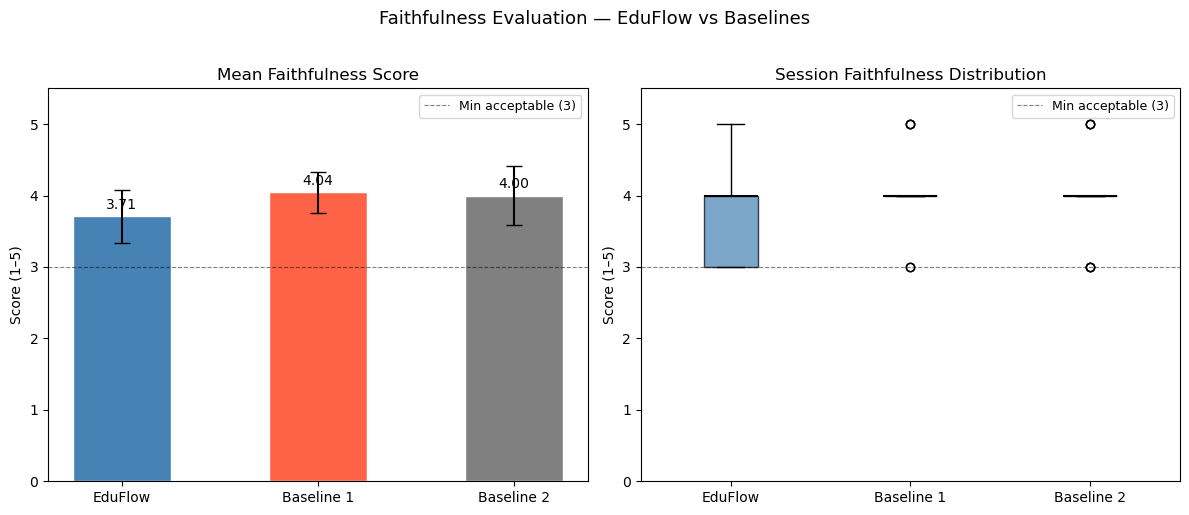

In [11]:
colors = {"EduFlow": "steelblue", "Baseline 1": "tomato", "Baseline 2": "gray"}
arch_order = ["EduFlow", "Baseline 1", "Baseline 2"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Plot 1: Mean faithfulness score + std error bars ──
means = [stats.loc[a, "Mean_Faithfulness_Score"] for a in arch_order]
stds  = [stats.loc[a, "Std_Faithfulness_Score"]  for a in arch_order]

bars = axes[0].bar(
    arch_order, means, yerr=stds,
    color=[colors[a] for a in arch_order],
    edgecolor="white", capsize=6, width=0.5
)
axes[0].set_title("Mean Faithfulness Score", fontsize=12)
axes[0].set_ylabel("Score (1–5)")
axes[0].set_ylim(0, 5.5)
axes[0].axhline(3, color="black", linestyle="--",
                linewidth=0.8, alpha=0.5, label="Min acceptable (3)")
axes[0].legend(fontsize=9)
for bar, val in zip(bars, means):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{val:.2f}", ha="center", fontsize=10
    )

# ── Plot 2: Per-session distribution (box plot) ──
data_by_arch = [
    df_sessions[df_sessions["Architecture"] == a]["faithfulness_score"].values
    for a in arch_order
]
bp = axes[1].boxplot(
    data_by_arch, tick_labels=arch_order, patch_artist=True,
    medianprops=dict(color="black", linewidth=1.5)
)
for patch, arch in zip(bp["boxes"], arch_order):
    patch.set_facecolor(colors[arch])
    patch.set_alpha(0.7)
axes[1].set_title("Session Faithfulness Distribution", fontsize=12)
axes[1].set_ylabel("Score (1–5)")
axes[1].set_ylim(0, 5.5)
axes[1].axhline(3, color="black", linestyle="--",
                linewidth=0.8, alpha=0.5, label="Min acceptable (3)")
axes[1].legend(fontsize=9)

plt.suptitle("Faithfulness Evaluation — EduFlow vs Baselines", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
volume = df.groupby("Architecture").agg(
    Mean_Total_Claims     = ("Total Claims", "mean"),
    Mean_Supported_Claims = ("Total Supported Claims", "mean"),
).round(1)

volume = volume.reindex(order)
print("=== Content Volume by Architecture ===")
print(volume.to_string())

=== Content Volume by Architecture ===
              Mean_Total_Claims  Mean_Supported_Claims
Architecture                                          
EduFlow                   130.2                  111.5
Baseline 1                109.5                   99.2
Baseline 2                108.0                   97.7


In [13]:
combined = stats.join(volume)
combined["Unsupported_Claims"] = (
    combined["Mean_Total_Claims"] - combined["Mean_Supported_Claims"]
).round(1)

print("=== Combined Faithfulness + Volume ===")
print(combined[["Runs", "Mean_Faithfulness_Score", "Std_Faithfulness_Score",
                "Mean_Total_Claims", "Mean_Supported_Claims", 
                "Unsupported_Claims"]].to_string())

=== Combined Faithfulness + Volume ===
              Runs  Mean_Faithfulness_Score  Std_Faithfulness_Score  Mean_Total_Claims  Mean_Supported_Claims  Unsupported_Claims
Architecture                                                                                                                     
EduFlow          6                    3.708                   0.368              130.2                  111.5                18.7
Baseline 1       6                    4.042                   0.292              109.5                   99.2                10.3
Baseline 2       6                    4.000                   0.418              108.0                   97.7                10.3


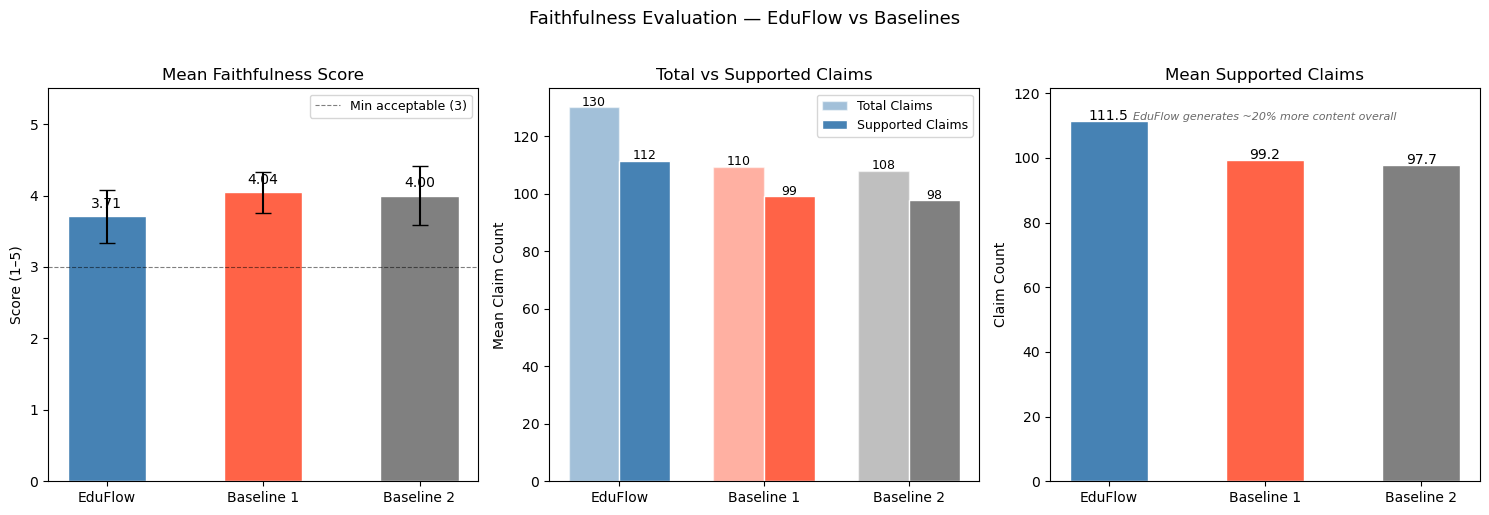

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

arch_order = ["EduFlow", "Baseline 1", "Baseline 2"]
colors = {"EduFlow": "steelblue", "Baseline 1": "tomato", "Baseline 2": "gray"}
color_list = [colors[a] for a in arch_order]

# ── Plot 1: Faithfulness Score ──
means = [stats.loc[a, "Mean_Faithfulness_Score"] for a in arch_order]
stds  = [stats.loc[a, "Std_Faithfulness_Score"]  for a in arch_order]

bars1 = axes[0].bar(arch_order, means, yerr=stds,
                    color=color_list, edgecolor="white", capsize=6, width=0.5)
axes[0].set_title("Mean Faithfulness Score", fontsize=12)
axes[0].set_ylabel("Score (1–5)")
axes[0].set_ylim(0, 5.5)
axes[0].axhline(3, color="black", linestyle="--", linewidth=0.8,
                alpha=0.5, label="Min acceptable (3)")
axes[0].legend(fontsize=9)
for bar, val in zip(bars1, means):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.12,
                 f"{val:.2f}", ha="center", fontsize=10)

# ── Plot 2: Total vs Supported Claims (grouped bar) ──
x = np.arange(len(arch_order))
width = 0.35

total_vals     = [combined.loc[a, "Mean_Total_Claims"]     for a in arch_order]
supported_vals = [combined.loc[a, "Mean_Supported_Claims"] for a in arch_order]

bars_total = axes[1].bar(x - width/2, total_vals, width,
                         label="Total Claims",
                         color=color_list, edgecolor="white", alpha=0.5)
bars_supp  = axes[1].bar(x + width/2, supported_vals, width,
                         label="Supported Claims",
                         color=color_list, edgecolor="white", alpha=1.0)

axes[1].set_title("Total vs Supported Claims", fontsize=12)
axes[1].set_ylabel("Mean Claim Count")
axes[1].set_xticks(x)
axes[1].set_xticklabels(arch_order)
axes[1].legend(fontsize=9)
for bar, val in zip(bars_total, total_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f"{val:.0f}", ha="center", fontsize=9)
for bar, val in zip(bars_supp, supported_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f"{val:.0f}", ha="center", fontsize=9)

# ── Plot 3: Mean Supported Claims ──
bars3 = axes[2].bar(arch_order, supported_vals,
                    color=color_list, edgecolor="white", width=0.5)
axes[2].set_title("Mean Supported Claims", fontsize=12)
axes[2].set_ylabel("Claim Count")
axes[2].set_ylim(0, max(supported_vals) + 10)
for bar, val in zip(bars3, supported_vals):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f"{val:.1f}", ha="center", fontsize=10)

# Add annotation explaining the confound
axes[2].text(0.5, 0.92,
             "EduFlow generates ~20% more content overall",
             transform=axes[2].transAxes,
             ha="center", fontsize=8, style="italic",
             color="dimgray")

plt.suptitle("Faithfulness Evaluation — EduFlow vs Baselines", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()